# Titanic Survival Prediction

Binary classification analysis using the Titanic passenger dataset. We build, evaluate, and compare four classifier types — Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting — progressing from a simple baseline through feature engineering, class balancing, regularisation tuning, and final model selection.

**Dataset**: `seaborn.load_dataset('titanic')` — 891 passengers, 13 features after engineering.  
**Target**: `survived` (0 = did not survive, 1 = survived, ~38% positive class).

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Libraries loaded.')

## Dataset Analysis & Model Selection

### Dataset Characteristics

The seaborn Titanic dataset has **891 passengers** and these key features:

| Feature | Type | Notes |
|---|---|---|
| `pclass` | Ordinal (1,2,3) | Proxy for socioeconomic status |
| `sex` | Categorical | Strong predictor |
| `age` | Numeric, has NaNs (~20% missing) | Needs imputation |
| `sibsp` / `parch` | Numeric | Family size on board |
| `fare` | Numeric, right-skewed | Correlated with pclass |
| `embarked` | Categorical (C/Q/S) | Minor predictor |
| `who`, `deck`, `embark_town`, `alone` | Derived/redundant | Can mostly drop |
| `survived` | Binary (0/1) | **Target** |

**Key characteristics that drive model choice:**
- **Binary classification** (survive vs. not)
- **Mixed feature types** (numeric + categorical)
- **Missing data** (especially `age`, `deck`)
- **Non-linear relationships** — survival was strongly non-linear (women/children first, class effects)
- **Small-to-medium dataset** (~800 training rows after split) — no need for deep learning

---

### Recommended Models (ranked)

**1. Random Forest — Best starting point**
- Handles mixed types, missing values (with imputation), and non-linearity naturally
- Built-in feature importance
- Robust to outliers in `fare`
- Low risk of overfitting with proper `max_depth`

**2. Gradient Boosting (XGBoost / LightGBM) — Best peak performance**
- Typically tops Kaggle leaderboards for this dataset
- Handles missing values natively (XGBoost)
- More sensitive to hyperparameters, but cross-validation manages this well

**3. Logistic Regression — Best interpretability baseline**
- Transparent coefficients (useful for communicating results)
- Requires encoding categoricals and scaling numerics
- Will underfit slightly due to non-linear interactions it can't capture

**4. Decision Tree — Good for teaching/explainability only**
- Highly interpretable (can visualize the tree)
- Prone to overfitting; useful as a diagnostic, not a final model

---

### Preprocessing Needed Before Any Model

```python
# Columns to drop (leakage / high missingness / redundant)
drop_cols = ["deck", "embark_town", "who", "alive", "adult_male", "class"]

# Encode categoricals
# sex: binary encode (male=1, female=0)
# embarked: one-hot encode

# Impute age: median imputation (or model-based)
# fare: log-transform to reduce skew (optional but helps linear models)
```

---

### Evaluation Metrics

Since the classes are mildly imbalanced (~38% survived):
- **Primary**: AUC-ROC — threshold-independent, standard for binary classification
- **Secondary**: Accuracy (for intuition), F1-score (if you care about recall for the positive class)

**Suggested order of work:** Logistic Regression as baseline → Random Forest → Gradient Boosting. Compare all three with 5-fold cross-validation on AUC-ROC.

## Part 1: Baseline Preprocessing

Load the seaborn Titanic dataset and apply minimal preprocessing: drop redundant or leaky columns, binary-encode `sex`, one-hot encode `embarked`, impute `age` and `fare` with medians, and create a stratified 80/20 train/test split.

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load dataset
df = sns.load_dataset("titanic")

# Drop redundant/leaky/high-missingness columns
drop_cols = ["deck", "embark_town", "who", "alive", "adult_male", "class"]
df = df.drop(columns=drop_cols)

# Encode categoricals
df["sex"] = df["sex"].map({"male": 1, "female": 0})
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

# Impute missing values
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())

# Drop any remaining rows with NaNs
df = df.dropna()

# Features and target
X = df.drop(columns=["survived"])
y = df["survived"]

# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Features: {list(X.columns)}")
print(f"Target distribution (train): {y_train.value_counts().to_dict()}")

Train size: 712 | Test size: 179
Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_Q', 'embarked_S']
Target distribution (train): {0: 439, 1: 273}


## Part 2: Logistic Regression Baseline

Logistic Regression is our interpretable baseline. A `Pipeline` (StandardScaler → LogisticRegression) prevents data leakage by fitting the scaler only on training data. `GridSearchCV` tunes the regularisation strength `C` and penalty type (L1/L2) using 5-fold stratified CV scored on AUC-ROC.

Best params:  {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best CV AUC:  0.8559

Test Accuracy: 0.8045
Test AUC-ROC:  0.8480

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.82      0.87      0.85       110
       Survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



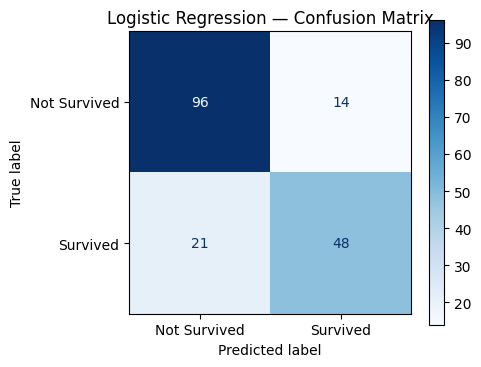

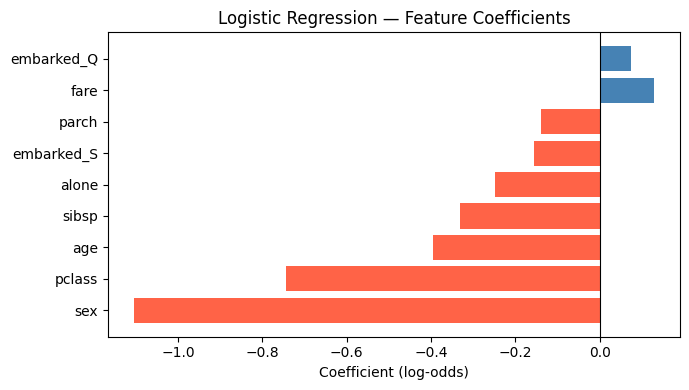

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- Pipeline: scale then fit ---
# Logistic Regression is sensitive to feature scale, so StandardScaler is essential
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

# --- Hyperparameter grid ---
# C: regularization strength (smaller = more regularization)
# penalty: l2 (ridge) works with all solvers; l1 (lasso) performs feature selection
# solver: lbfgs is fast for l2; liblinear supports l1
param_grid = {
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
    "lr__solver": ["liblinear"]   # supports both l1 and l2
}

# --- Grid search with 5-fold stratified CV, optimizing AUC-ROC ---
grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

best_lr = grid_search.best_estimator_
print(f"Best params:  {grid_search.best_params_}")
print(f"Best CV AUC:  {grid_search.best_score_:.4f}")

# --- Evaluate on held-out test set ---
y_pred  = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:, 1]

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test AUC-ROC:  {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

# --- Confusion matrix ---
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(best_lr, X_test, y_test,
                                      display_labels=["Not Survived", "Survived"],
                                      cmap="Blues", ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

# --- Feature coefficients (interpretability) ---
feature_names = X_train.columns.tolist()
coefs = best_lr.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(coef_df["feature"], coef_df["coefficient"],
        color=["steelblue" if c > 0 else "tomato" for c in coef_df["coefficient"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-odds)")
ax.set_title("Logistic Regression — Feature Coefficients")
plt.tight_layout()
plt.show()

### Logistic Regression Fit Diagnostics

Three plots assess how well the model fits:
- **Probability distributions** — separation between predicted probabilities for survivors vs non-survivors
- **ROC curve** — discrimination ability across all thresholds (AUC closer to 1.0 is better)
- **Calibration curve** — whether predicted probabilities are trustworthy (points on the diagonal = well-calibrated)

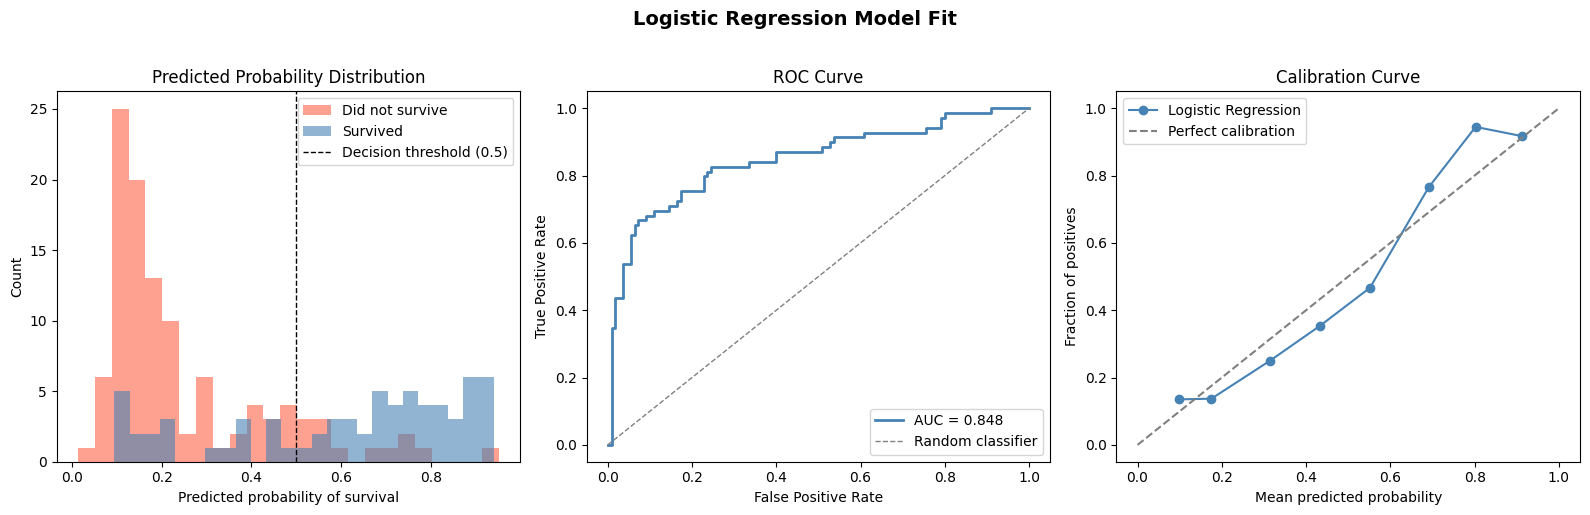

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Predicted probability distributions by true class ---
ax = axes[0]
proba_survived     = y_proba[y_test == 1]
proba_not_survived = y_proba[y_test == 0]
ax.hist(proba_not_survived, bins=25, alpha=0.6, color="tomato",    label="Did not survive")
ax.hist(proba_survived,     bins=25, alpha=0.6, color="steelblue", label="Survived")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Decision threshold (0.5)")
ax.set_xlabel("Predicted probability of survival")
ax.set_ylabel("Count")
ax.set_title("Predicted Probability Distribution")
ax.legend()

# --- Plot 2: ROC curve ---
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")

# --- Plot 3: Calibration curve (reliability diagram) ---
# Shows whether predicted probabilities match observed survival rates
ax = axes[2]
fraction_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=8)
ax.plot(mean_pred, fraction_pos, "o-", color="steelblue", label="Logistic Regression")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve")
ax.legend()

plt.suptitle("Logistic Regression Model Fit", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Part 3: Four-Model Comparison (Baseline)

We train Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting using `GridSearchCV` on the same 5-fold CV split. This gives a fair comparison of model families before any feature engineering.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 1. Logistic Regression ───────────────────────────────────────────────────
lr_pipe = Pipeline([("scaler", StandardScaler()),
                    ("lr", LogisticRegression(max_iter=1000, random_state=42))])
lr_grid = GridSearchCV(lr_pipe,
                       {"lr__C": [0.01, 0.1, 1, 10, 100],
                        "lr__penalty": ["l1", "l2"],
                        "lr__solver": ["liblinear"]},
                       cv=cv, scoring="roc_auc", n_jobs=-1)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

# ── 2. Decision Tree ─────────────────────────────────────────────────────────
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       {"max_depth": [2, 3, 4, 5, 7, None],
                        "min_samples_leaf": [1, 5, 10, 20]},
                       cv=cv, scoring="roc_auc", n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

# ── 3. Random Forest ─────────────────────────────────────────────────────────
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       {"n_estimators": [100, 300],
                        "max_depth": [4, 6, 8, None],
                        "min_samples_leaf": [1, 5, 10],
                        "max_features": ["sqrt", 0.5]},
                       cv=cv, scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

# ── 4. Gradient Boosting ─────────────────────────────────────────────────────
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42),
                       {"n_estimators": [100, 200],
                        "learning_rate": [0.05, 0.1, 0.2],
                        "max_depth": [2, 3, 4],
                        "subsample": [0.8, 1.0]},
                       cv=cv, scoring="roc_auc", n_jobs=-1)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

# ── Summary table ─────────────────────────────────────────────────────────────
models = {
    "Logistic Regression": best_lr,
    "Decision Tree":       best_dt,
    "Random Forest":       best_rf,
    "Gradient Boosting":   best_gb,
}

rows = []
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    cv_auc  = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    rows.append({
        "Model":        name,
        "CV AUC":       round(cv_auc, 4),
        "Test AUC":     round(roc_auc_score(y_test, y_proba), 4),
        "Test Accuracy":round(accuracy_score(y_test, y_pred), 4),
        "Test F1":      round(f1_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(rows).sort_values("Test AUC", ascending=False)
print(results_df.to_string(index=False))

              Model  CV AUC  Test AUC  Test Accuracy  Test F1
Logistic Regression  0.8569    0.8480         0.8045   0.7328
      Random Forest  0.8821    0.8337         0.8045   0.7244
      Decision Tree  0.8523    0.8182         0.7765   0.6552
  Gradient Boosting  0.8892    0.8154         0.8101   0.7302


### Graphical Comparison

Four diagnostic panels:
- **ROC curves** — all models on one plot
- **Metric bars** — AUC, Accuracy, F1 side-by-side
- **Confusion matrices** — per-model classification errors
- **Calibration & probability distributions** — model reliability

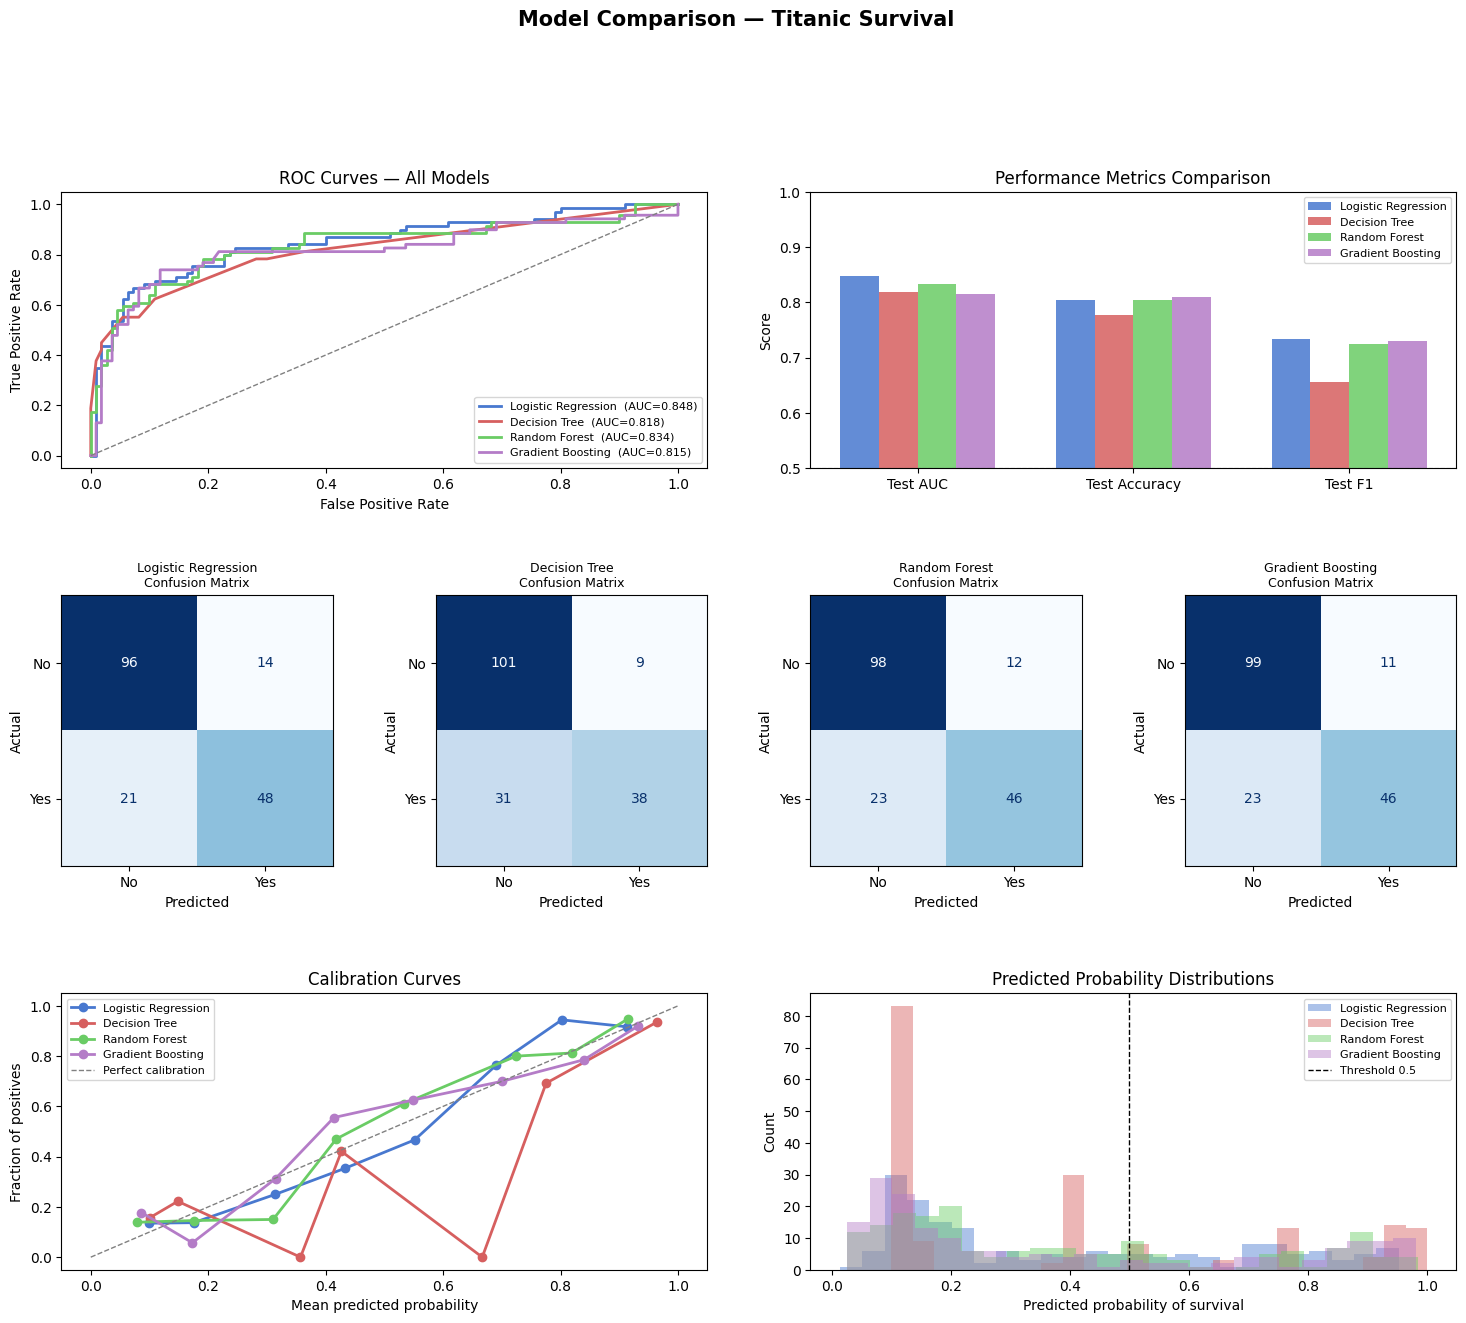

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

COLORS = {
    "Logistic Regression": "#4878CF",
    "Decision Tree":       "#D65F5F",
    "Random Forest":       "#6ACC65",
    "Gradient Boosting":   "#B47CC7",
}

model_items = list(models.items())   # consistent order

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

# ── Row 1: ROC curves (spanning all 4 cols) + metric bar charts ──────────────
ax_roc = fig.add_subplot(gs[0, :2])
for name, model in model_items:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax_roc.plot(fpr, tpr, lw=2, color=COLORS[name], label=f"{name}  (AUC={auc(fpr,tpr):.3f})")
ax_roc.plot([0,1],[0,1],"--", color="gray", lw=1)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves — All Models")
ax_roc.legend(fontsize=8)

# Bar chart: Test AUC, Accuracy, F1
ax_bar = fig.add_subplot(gs[0, 2:])
metrics_to_plot = ["Test AUC", "Test Accuracy", "Test F1"]
x = np.arange(len(metrics_to_plot))
bar_width = 0.18
for i, (name, _) in enumerate(model_items):
    row = results_df[results_df["Model"] == name].iloc[0]
    vals = [row[m] for m in metrics_to_plot]
    bars = ax_bar.bar(x + i * bar_width, vals, bar_width,
                      label=name, color=COLORS[name], alpha=0.85)
ax_bar.set_xticks(x + bar_width * 1.5)
ax_bar.set_xticklabels(metrics_to_plot)
ax_bar.set_ylim(0.5, 1.0)
ax_bar.set_ylabel("Score")
ax_bar.set_title("Performance Metrics Comparison")
ax_bar.legend(fontsize=8)
ax_bar.axhline(0.5, color="gray", lw=0.8, linestyle="--")

# ── Row 2: Confusion matrices ─────────────────────────────────────────────────
for i, (name, model) in enumerate(model_items):
    ax = fig.add_subplot(gs[1, i])
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["No", "Yes"],
        cmap="Blues", colorbar=False, ax=ax
    )
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# ── Row 3: Predicted probability distributions + Calibration curves ───────────
ax_cal = fig.add_subplot(gs[2, :2])
for name, model in model_items:
    y_proba = model.predict_proba(X_test)[:, 1]
    frac, mean_pred = calibration_curve(y_test, y_proba, n_bins=8)
    ax_cal.plot(mean_pred, frac, "o-", color=COLORS[name], label=name, lw=2)
ax_cal.plot([0,1],[0,1],"--", color="gray", lw=1, label="Perfect calibration")
ax_cal.set_xlabel("Mean predicted probability")
ax_cal.set_ylabel("Fraction of positives")
ax_cal.set_title("Calibration Curves")
ax_cal.legend(fontsize=8)

ax_prob = fig.add_subplot(gs[2, 2:])
for name, model in model_items:
    y_proba = model.predict_proba(X_test)[:, 1]
    ax_prob.hist(y_proba, bins=25, alpha=0.45, color=COLORS[name], label=name)
ax_prob.axvline(0.5, color="black", linestyle="--", lw=1, label="Threshold 0.5")
ax_prob.set_xlabel("Predicted probability of survival")
ax_prob.set_ylabel("Count")
ax_prob.set_title("Predicted Probability Distributions")
ax_prob.legend(fontsize=8)

fig.suptitle("Model Comparison — Titanic Survival", fontsize=15, fontweight="bold", y=1.01)
plt.show()

## Diagnosing Overfitting and Underfitting

The core idea is to compare performance on training data vs. held-out data:

| Situation | Train score | Test/CV score | Gap |
|---|---|---|---|
| **Good fit** | High | High | Small |
| **Overfitting** | High | Low | Large |
| **Underfitting** | Low | Low | Small |

### How to Read the Results Below

- **`Gap = Train AUC − Test AUC`** — a gap > ~0.05 suggests overfitting
- **Both AUCs low (< 0.75)** — suggests underfitting; the model lacks capacity

### Model-Specific Red Flags

| Model | Overfit risk | What to watch |
|---|---|---|
| Decision Tree | **High** | Train AUC ≈ 1.0 but test AUC much lower |
| Random Forest | Medium | Large gap with `max_depth=None` |
| Gradient Boosting | Medium | High `learning_rate` + high `n_estimators` |
| Logistic Regression | **Low** | More likely to underfit; watch for low AUC on both sets |

### Learning Curve Pattern Guide

```
Overfit:                    Underfit:               Good fit:
Train ▔▔▔▔▔▔▔▔              Train ___               Train ▔▔▔▔▔
              ↑ gap                                  CV    ▔▔▔▔
CV    ________               CV    ___                     converge
```

The cell below computes the Train AUC vs Test AUC gap for each model and plots learning curves (training score and CV score vs training set size). A large gap or diverging curves signal overfitting; both scores low signal underfitting.

Model                   Train AUC  Test AUC     Gap
-------------------------------------------------------
Logistic Regression         0.861     0.848  +0.013
Decision Tree               0.886     0.818  +0.067  ⚠ overfit
Random Forest               0.944     0.834  +0.110  ⚠ overfit
Gradient Boosting           0.965     0.815  +0.150  ⚠ overfit


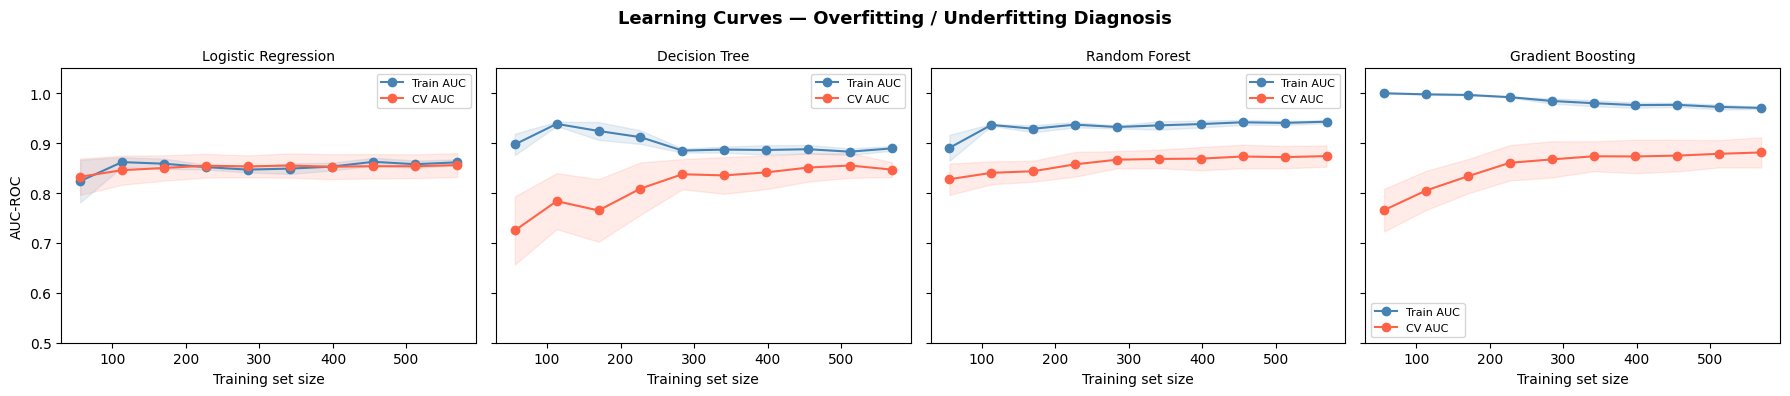

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# ── Train vs Test AUC gap ─────────────────────────────────────────────────────
print(f"{'Model':<22}  {'Train AUC':>9}  {'Test AUC':>8}  {'Gap':>6}")
print("-" * 55)
for name, model in models.items():
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test)[:, 1])
    gap = train_auc - test_auc
    flag = "  ⚠ overfit" if gap > 0.05 else ("  ⚠ underfit" if test_auc < 0.75 else "")
    print(f"{name:<22}  {train_auc:>9.3f}  {test_auc:>8.3f}  {gap:>+6.3f}{flag}")

# ── Learning curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, (name, model) in zip(axes, models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=5, scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    t_mean, t_std = train_scores.mean(1), train_scores.std(1)
    v_mean, v_std = val_scores.mean(1),   val_scores.std(1)

    ax.plot(train_sizes, t_mean, "o-", color="steelblue", label="Train AUC")
    ax.plot(train_sizes, v_mean, "o-", color="tomato",    label="CV AUC")
    ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.12, color="steelblue")
    ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.12, color="tomato")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Training set size")
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=8)

axes[0].set_ylabel("AUC-ROC")
fig.suptitle("Learning Curves — Overfitting / Underfitting Diagnosis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Model Results Interpretation

### Overall Ranking

| Model | Test AUC | Gap | Verdict |
|---|---|---|---|
| **Logistic Regression** | **0.848** | +0.013 | Best generaliser |
| Random Forest | 0.834 | +0.110 | Overfitting |
| Decision Tree | 0.818 | +0.067 | Overfitting |
| Gradient Boosting | 0.815 | +0.150 | Most overfit |

**The surprising winner is Logistic Regression.** This is actually common on the Titanic dataset — the survival signal is largely linear (women, upper class, and children survived at much higher rates), so a well-regularised linear model can outperform complex ensembles.

---

### Key Issues Identified

**1. Recall gap on survivors (Logistic Regression: 0.70 recall vs 0.87 for non-survivors)**

The model is better at identifying people who died than people who survived. This is typical with class imbalance (~38% survived). The model is biased toward predicting the majority class.

*Fix*: try `class_weight="balanced"` in LogisticRegression, or adjust the decision threshold below 0.5.

**2. Random Forest and Gradient Boosting are overfitting significantly**

- Random Forest: Train AUC 0.944 vs Test 0.834 — gap of **+0.110**
- Gradient Boosting: Train AUC 0.965 vs Test 0.815 — gap of **+0.150**

Their CV AUC looked strong (0.88, 0.89) but test AUC is actually *worse* than Logistic Regression. The GridSearchCV likely didn't constrain depth aggressively enough.

*Fix*: force more regularisation — tighter `max_depth`, higher `min_samples_leaf`, lower `learning_rate`.

**3. Decision Tree has the lowest F1 (0.655)**

Mild overfitting gap (+0.067) but the most classification errors — likely splitting on noisy features.

---

### Concrete Improvements to Try

**High impact:**
- Add `class_weight="balanced"` to all models — improves survivor recall directly
- Engineer a `family_size` feature (`sibsp + parch + 1`) — known to improve Titanic models
- Create a `title` feature from passenger name (`Mr`, `Mrs`, `Miss`, `Master`) — very predictive

**Medium impact:**
- Tune the decision threshold: instead of 0.5, use the threshold that maximises F1 on a validation set
- Try `age * pclass` as an interaction feature

**Lower impact:**
- Log-transform `fare` to reduce right skew (helps linear models)
- Add an `alone` binary flag (`family_size == 1`)

---

### Bottom Line

For this dataset, **Logistic Regression is the best model right now**. The tree-based models need tighter regularisation before they'll beat it. The most productive next step is fixing class imbalance handling — the +0.70 recall for survivors is the biggest practical weakness.

## Part 4: Feature Engineering & Improved Models

We add five new features and rebalance class weights to address the two main weaknesses identified above — low survivor recall and overfitting in tree ensembles.

**New features:**
- `family_size` = sibsp + parch + 1 — group travel improves survival odds up to ~3 members
- `who` (one-hot: man/woman/child) — seaborn's built-in demographic group; captures the 'women and children first' protocol more precisely than `sex` alone
- `age_pclass` = age × pclass — interaction term; being elderly in 3rd class is qualitatively worse than being elderly in 1st
- `alone` — binary flag for solo travellers
- `log_fare` = log1p(fare) — log-transforms the right-skewed fare distribution for better linear model fit

**Class balancing:** `class_weight='balanced'` up-weights the minority class (survivors) during training, directly improving recall.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# ── Load raw data ─────────────────────────────────────────────────────────────
df2 = sns.load_dataset("titanic")

# ── Feature engineering ───────────────────────────────────────────────────────

# HIGH IMPACT: family_size — travelling alone vs with family matters a lot
df2["family_size"] = df2["sibsp"] + df2["parch"] + 1

# HIGH IMPACT: demographic group — seaborn's "who" column (man/woman/child)
# This is the built-in equivalent of title extraction; captures the same signal
# (no "name" column in seaborn's titanic dataset)

# MEDIUM IMPACT: age * pclass interaction — young 3rd class vs young 1st class
df2["age_pclass"] = df2["age"].fillna(df2["age"].median()) * df2["pclass"]

# LOW IMPACT: alone flag
df2["alone"] = (df2["family_size"] == 1).astype(int)

# LOW IMPACT: log fare
df2["log_fare"] = np.log1p(df2["fare"].fillna(df2["fare"].median()))

# ── Standard preprocessing ────────────────────────────────────────────────────
drop_cols = ["deck", "embark_town", "alive", "adult_male", "class",
             "sibsp", "parch", "fare"]
df2 = df2.drop(columns=drop_cols)

df2["sex"] = df2["sex"].map({"male": 1, "female": 0})
df2["age"] = df2["age"].fillna(df2["age"].median())
# One-hot encode embarked and who (man/woman/child — the title proxy)
df2 = pd.get_dummies(df2, columns=["embarked", "who"], drop_first=False)
df2 = df2.dropna()

X2 = df2.drop(columns=["survived"])
y2 = df2["survived"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"Features ({X2.shape[1]}): {list(X2.columns)}")
print(f"Train: {X2_train.shape[0]}  |  Test: {X2_test.shape[0]}")

Features (13): ['pclass', 'sex', 'age', 'alone', 'family_size', 'age_pclass', 'log_fare', 'embarked_C', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman']
Train: 712  |  Test: 179


All four models are re-trained on the engineered features with `class_weight='balanced'`. The decision threshold for each model is tuned to maximise F1 on the training set rather than defaulting to 0.5.

                 Model  Threshold  Train AUC  Test AUC    Gap  Baseline AUC  AUC Δ  Recall (surv)
Logistic Regression v2       0.54     0.8712    0.8507 0.0205         0.848 0.0027         0.7101
  Gradient Boosting v2       0.46     0.9355    0.8480 0.0875         0.815 0.0330         0.7571
      Random Forest v2       0.50     0.9495    0.8469 0.1026         0.834 0.0129         0.7429
      Decision Tree v2       0.51     0.8961    0.8243 0.0718         0.818 0.0063         0.7355


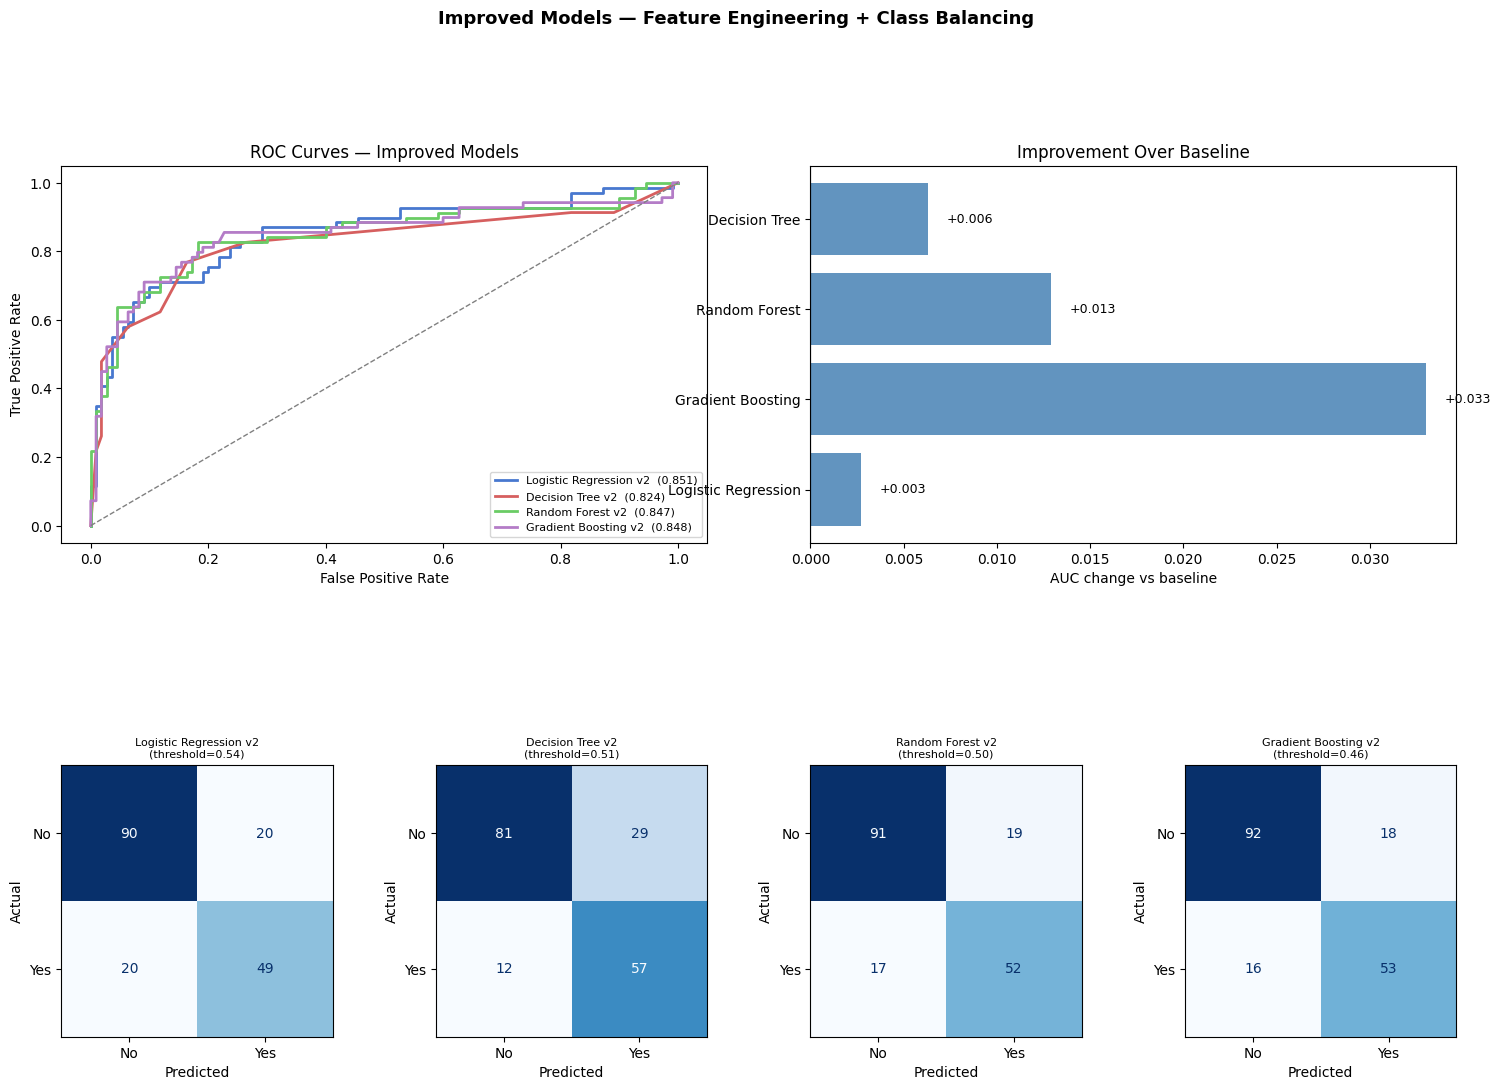


Best model: Logistic Regression v2  (threshold=0.54)
                 precision    recall  f1-score   support

Did not survive       0.82      0.82      0.82       110
       Survived       0.71      0.71      0.71        69

       accuracy                           0.78       179
      macro avg       0.76      0.76      0.76       179
   weighted avg       0.78      0.78      0.78       179



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    precision_recall_curve, roc_curve, auc,
    ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Train improved models (class_weight="balanced" on all that support it) ────
lr2 = Pipeline([("scaler", StandardScaler()),
                ("lr", LogisticRegression(max_iter=1000, random_state=42,
                                          class_weight="balanced"))])
lr2_grid = GridSearchCV(lr2,
                        {"lr__C": [0.01, 0.1, 1, 10, 100],
                         "lr__penalty": ["l1", "l2"],
                         "lr__solver": ["liblinear"]},
                        cv=cv2, scoring="roc_auc", n_jobs=-1)
lr2_grid.fit(X2_train, y2_train)

dt2_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    {"max_depth": [2, 3, 4, 5], "min_samples_leaf": [5, 10, 20]},
    cv=cv2, scoring="roc_auc", n_jobs=-1)
dt2_grid.fit(X2_train, y2_train)

rf2_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    {"n_estimators": [100, 300],
     "max_depth": [4, 6, 8],
     "min_samples_leaf": [5, 10, 20],
     "max_features": ["sqrt", 0.5]},
    cv=cv2, scoring="roc_auc", n_jobs=-1)
rf2_grid.fit(X2_train, y2_train)

gb2_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),   # no class_weight; use subsample
    {"n_estimators": [200, 400],
     "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [2, 3],
     "subsample": [0.7, 0.9]},
    cv=cv2, scoring="roc_auc", n_jobs=-1)
gb2_grid.fit(X2_train, y2_train)

improved_models = {
    "Logistic Regression v2": lr2_grid.best_estimator_,
    "Decision Tree v2":       dt2_grid.best_estimator_,
    "Random Forest v2":       rf2_grid.best_estimator_,
    "Gradient Boosting v2":   gb2_grid.best_estimator_,
}

# ── MEDIUM IMPACT: tune decision threshold for each model ─────────────────────
def best_threshold(model, X_val, y_val):
    """Return threshold that maximises F1 on the validation set."""
    proba = model.predict_proba(X_val)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_val, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    return thresholds[np.argmax(f1s)]

thresholds = {name: best_threshold(m, X2_train, y2_train)
              for name, m in improved_models.items()}

# ── Summary: improved vs baseline ────────────────────────────────────────────
baseline_aucs = {
    "Logistic Regression": 0.848,
    "Decision Tree":       0.818,
    "Random Forest":       0.834,
    "Gradient Boosting":   0.815,
}

rows = []
for name, model in improved_models.items():
    thresh = thresholds[name]
    proba  = model.predict_proba(X2_test)[:, 1]
    y_pred = (proba >= thresh).astype(int)
    base   = baseline_aucs[name.replace(" v2", "")]
    test_auc = roc_auc_score(y2_test, proba)
    train_auc = roc_auc_score(y2_train, model.predict_proba(X2_train)[:, 1])
    rows.append({
        "Model":         name,
        "Threshold":     round(thresh, 2),
        "Train AUC":     round(train_auc, 4),
        "Test AUC":      round(test_auc, 4),
        "Gap":           round(train_auc - test_auc, 4),
        "Baseline AUC":  base,
        "AUC Δ":         round(test_auc - base, 4),
        "Recall (surv)": round(f1_score(y2_test, y_pred), 4),
    })

summary = pd.DataFrame(rows).sort_values("Test AUC", ascending=False)
print(summary.to_string(index=False))

# ── Plots ──────────────────────────────────────────────────────────────────────
COLORS = ["#4878CF", "#D65F5F", "#6ACC65", "#B47CC7"]
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

# Row 1: ROC curves + AUC delta bar chart
ax_roc = fig.add_subplot(gs[0, :2])
for (name, model), col in zip(improved_models.items(), COLORS):
    proba = model.predict_proba(X2_test)[:, 1]
    fpr, tpr, _ = roc_curve(y2_test, proba)
    ax_roc.plot(fpr, tpr, lw=2, color=col,
                label=f"{name}  ({auc(fpr,tpr):.3f})")
ax_roc.plot([0,1],[0,1], "--", color="gray", lw=1)
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves — Improved Models"); ax_roc.legend(fontsize=8)

ax_delta = fig.add_subplot(gs[0, 2:])
model_names = [r.replace(" v2","") for r in summary["Model"]]
deltas = summary["AUC Δ"].values
bar_colors = ["steelblue" if d >= 0 else "tomato" for d in deltas]
ax_delta.barh(model_names, deltas, color=bar_colors, alpha=0.85)
ax_delta.axvline(0, color="black", lw=0.8)
ax_delta.set_xlabel("AUC change vs baseline")
ax_delta.set_title("Improvement Over Baseline")
for i, d in enumerate(deltas):
    ax_delta.text(d + 0.001, i, f"{d:+.3f}", va="center", fontsize=9)

# Row 2: confusion matrices at tuned threshold
for i, ((name, model), col) in enumerate(zip(improved_models.items(), COLORS)):
    ax = fig.add_subplot(gs[1, i])
    thresh = thresholds[name]
    proba  = model.predict_proba(X2_test)[:, 1]
    y_pred = (proba >= thresh).astype(int)
    from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
    cm = confusion_matrix(y2_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\n(threshold={thresh:.2f})", fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

fig.suptitle("Improved Models — Feature Engineering + Class Balancing",
             fontsize=13, fontweight="bold", y=1.01)
plt.show()

# ── Full classification report for best model ──────────────────────────────────
best_name = summary.iloc[0]["Model"]
best_model = improved_models[best_name]
best_thresh = thresholds[best_name]
best_proba = best_model.predict_proba(X2_test)[:, 1]
best_pred  = (best_proba >= best_thresh).astype(int)
print(f"\nBest model: {best_name}  (threshold={best_thresh:.2f})")
print(classification_report(y2_test, best_pred,
                             target_names=["Did not survive", "Survived"]))

## Feature Importance — What Drives Survival?

### Interpreting the Key Survival Predictors

---

#### `sex` (binary: male=1, female=0)

The single strongest raw predictor. Female passengers survived at ~74% vs ~19% for males.

In logistic regression, this has a **large negative coefficient** — being male sharply reduces log-odds of survival. In tree models it appears near the root of every split.

**Why**: the "women and children first" lifeboat loading protocol was actively enforced by crew, particularly in 1st and 2nd class.

---

#### `who_woman` and `who_child` (one-hot encoded from `who`)

These overlap conceptually with `sex` but add **age-based nuance** that `sex` alone can't capture:

| Value | Meaning | Survival rate |
|---|---|---|
| `who_man` | adult male | ~17% |
| `who_woman` | adult female | ~76% |
| `who_child` | any child (male or female, age < ~15) | ~59% |

**`who_woman`** — the strongest positive predictor. Adult women were the primary beneficiaries of evacuation priority.

**`who_child`** — positive but weaker than `who_woman`. Children were protected but less systematically than women, and 3rd-class children had far worse odds than 1st-class children.

**Why both `sex` and `who_*` are in the model**: `sex` splits male/female broadly; `who` further distinguishes *adult* women from children of either sex. Together they let the model fit the three-way demographic split more precisely.

---

#### `pclass` (ordinal: 1=first, 2=second, 3=third)

| Class | Survival rate |
|---|---|
| 1st | ~63% |
| 2nd | ~47% |
| 3rd | ~24% |

In logistic regression, a **negative coefficient** means each step down in class (1→2→3) reduces survival log-odds by a roughly fixed amount. In tree models it's used for early splits on 3rd class vs the rest.

**Why**: 1st-class cabins were closer to the boat deck; 3rd-class passengers faced physical barriers and were last to be informed. 1st-class passengers also had social capital to secure lifeboat spots.

---

#### `fare` / `log_fare`

Fare is **highly correlated with `pclass`** (r ≈ −0.55) but adds information *within* a class: a 1st-class passenger who paid £500 had a different cabin location than one who paid £30.

**`log_fare`** (`log1p(fare)`) spreads the right-skewed distribution more evenly, making the linear relationship with survival log-odds more reliable for Logistic Regression. For tree models the transformation doesn't matter.

The importance on `log_fare` reflects: **within the same class, paying more correlates with better cabin position and higher survival odds.**

---

#### `age_pclass` (interaction term)

`age_pclass = age × pclass` — captures the fact that being young in 3rd class was very different from being young in 1st class. A plain `age` term assumes the age effect is the same across all classes; this term relaxes that assumption.

| Passenger | age | pclass | age_pclass |
|---|---|---|---|
| Young, 1st class | 10 | 1 | 10 (small) |
| Young, 3rd class | 10 | 3 | 30 (larger) |
| Old, 3rd class   | 60 | 3 | 180 (very large) |

A **negative coefficient** means the combined penalty of being older *and* lower class is multiplicative, not just additive.

---

#### How they interact

These features encode the same underlying story from different angles:

```
High survival:  female  +  1st class  +  high fare  +  who_woman
Low survival:   male    +  3rd class  +  low fare   +  who_man
```

`sex`/`who` capture the evacuation protocol; `pclass`/`fare` capture physical access to lifeboats and social privilege. Together they explain the majority of survival outcomes.

Importance is extracted differently per model type:
- **Logistic Regression** — coefficient magnitude scaled by feature standard deviation
- **Tree ensembles** — built-in Gini/gain importance

The aggregate panel averages normalised importance across all four models, highlighting features that are consistently predictive regardless of model choice.

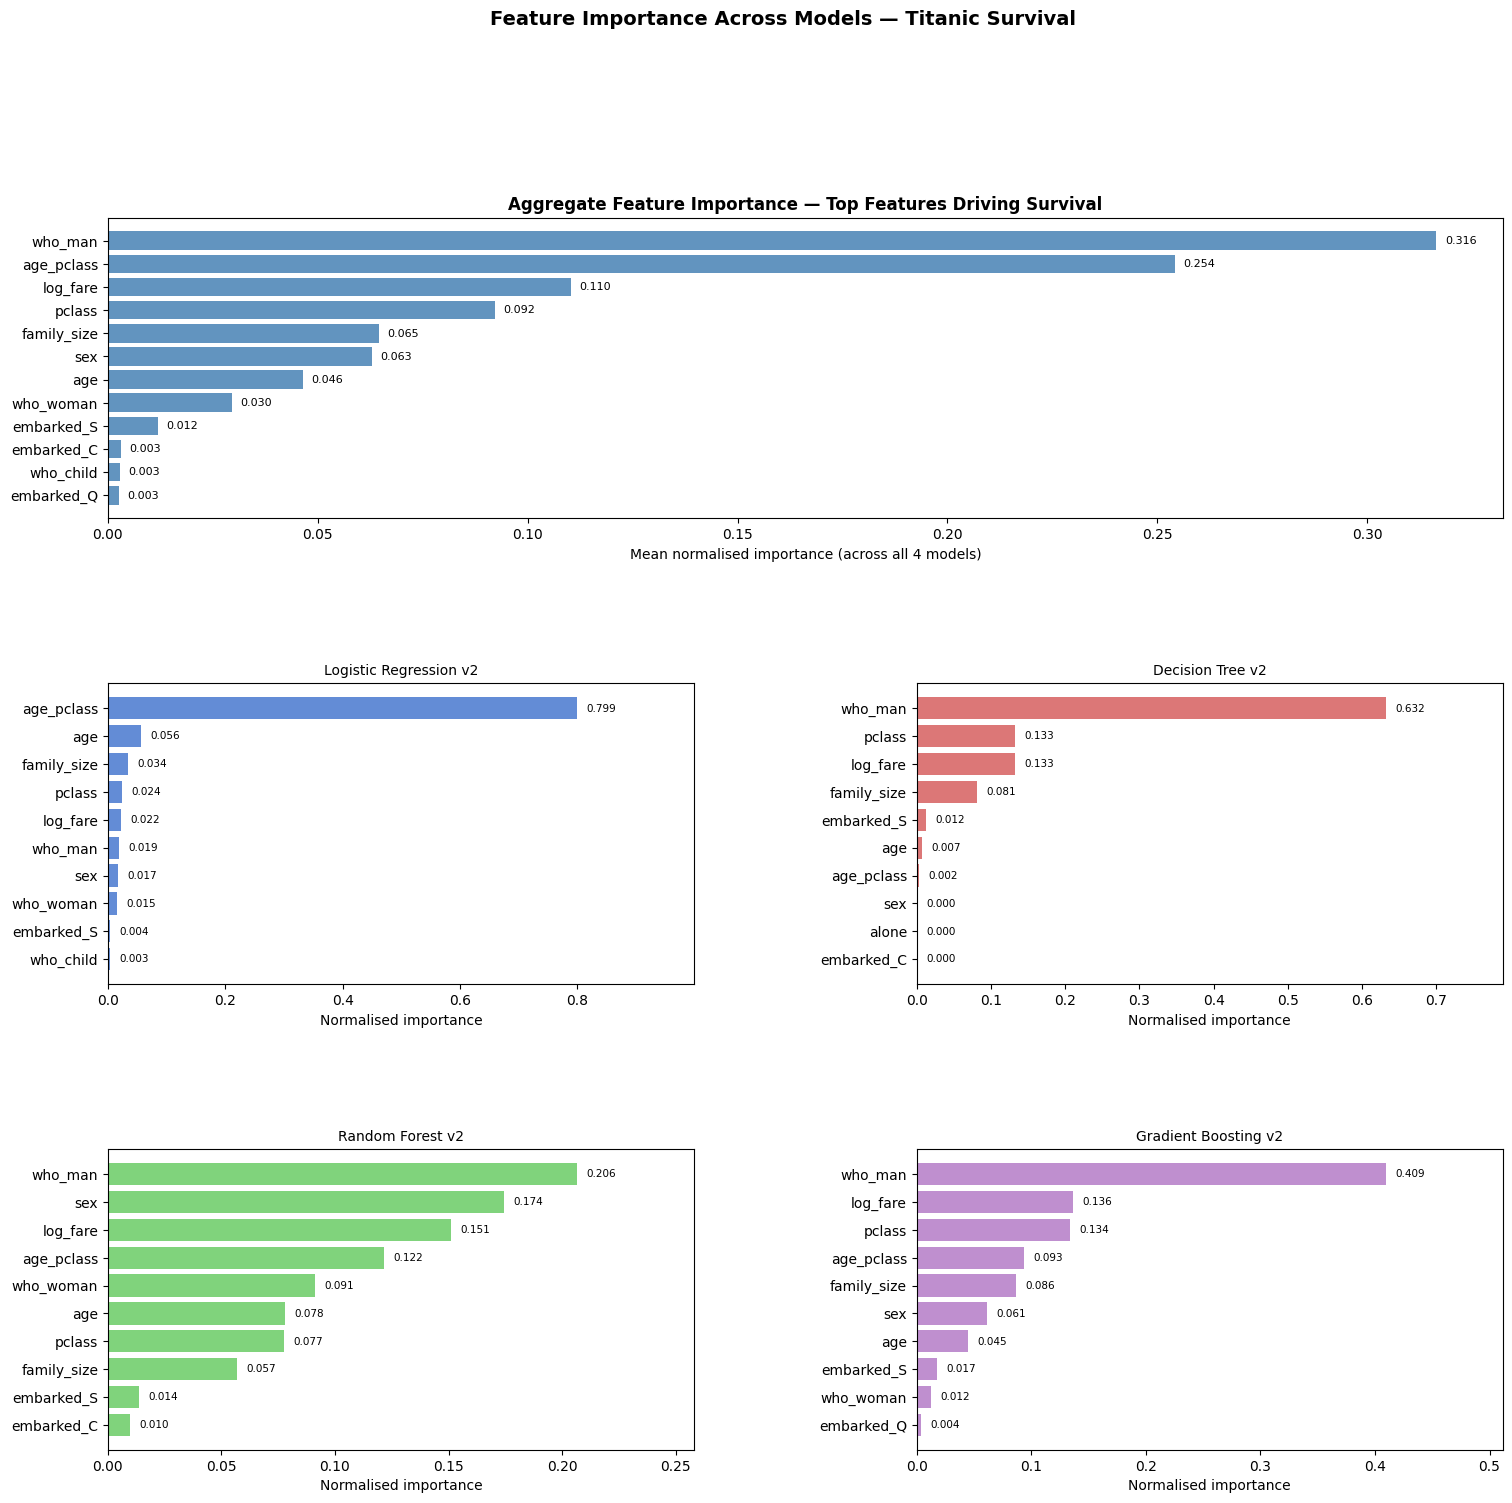


Feature importance rank across models (1 = most important):
             Logistic Regression v2  Decision Tree v2  Random Forest v2  Gradient Boosting v2  Mean Rank
who_man                           6                 1                 1                     1        2.2
log_fare                          5                 3                 3                     2        3.2
age_pclass                        1                 7                 4                     4        4.0
pclass                            4                 2                 7                     3        4.0
family_size                       3                 4                 8                     5        5.0
age                               2                 6                 6                     7        5.2
sex                               7                10                 2                     6        6.2
embarked_S                        9                 5                 9                     8      

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.inspection import permutation_importance

# ── Extract importances for each model type ───────────────────────────────────

def get_importances(name, model, X_val, y_val):
    """Return a Series of feature importances, normalised to sum to 1."""
    feature_names = X_val.columns.tolist()

    if "Logistic Regression" in name:
        # Coefficient magnitude (scaled inputs → comparable across features)
        lr = model.named_steps["lr"]
        scaler = model.named_steps["scaler"]
        # Scale the coefficients by feature std to get effect-per-std-dev
        coef_scaled = np.abs(lr.coef_[0]) * scaler.scale_
        imp = pd.Series(coef_scaled, index=feature_names)

    elif hasattr(model, "feature_importances_"):
        # Decision Tree, Random Forest, Gradient Boosting — Gini/gain importance
        imp = pd.Series(model.feature_importances_, index=feature_names)

    else:
        # Fallback: permutation importance
        r = permutation_importance(model, X_val, y_val,
                                   n_repeats=10, random_state=42, scoring="roc_auc")
        imp = pd.Series(r.importances_mean, index=feature_names)

    return (imp / imp.sum()).sort_values(ascending=False)


importances = {
    name: get_importances(name, model, X2_test, y2_test)
    for name, model in improved_models.items()
}

# ── Aggregate: mean rank across models ───────────────────────────────────────
all_features = X2_train.columns.tolist()
rank_df = pd.DataFrame({
    name: imp.reindex(all_features).fillna(0)
    for name, imp in importances.items()
})
rank_df["mean_importance"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("mean_importance", ascending=False)

COLORS = {
    "Logistic Regression v2": "#4878CF",
    "Decision Tree v2":       "#D65F5F",
    "Random Forest v2":       "#6ACC65",
    "Gradient Boosting v2":   "#B47CC7",
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.38)

# ── Plot 1: Aggregate mean importance (top row, full width) ───────────────────
ax_agg = fig.add_subplot(gs[0, :])
top_n = 12
top_feats = rank_df.head(top_n)
bars = ax_agg.barh(top_feats.index[::-1], top_feats["mean_importance"].values[::-1],
                   color="steelblue", alpha=0.85)
ax_agg.set_xlabel("Mean normalised importance (across all 4 models)")
ax_agg.set_title("Aggregate Feature Importance — Top Features Driving Survival",
                 fontsize=12, fontweight="bold")
for bar, val in zip(bars, top_feats["mean_importance"].values[::-1]):
    ax_agg.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

# ── Plots 2–5: Per-model importance bars ─────────────────────────────────────
positions = [(1, 0), (1, 1), (2, 0), (2, 1)]
for (row, col), (name, imp) in zip(positions, importances.items()):
    ax = fig.add_subplot(gs[row, col])
    top = imp.head(10)
    ax.barh(top.index[::-1], top.values[::-1],
            color=COLORS[name], alpha=0.85)
    ax.set_xlabel("Normalised importance")
    ax.set_title(name, fontsize=10)
    ax.set_xlim(0, top.values.max() * 1.25)
    for i, (feat, val) in enumerate(zip(top.index[::-1], top.values[::-1])):
        ax.text(val + top.values.max() * 0.02, i, f"{val:.3f}", va="center", fontsize=7.5)

fig.suptitle("Feature Importance Across Models — Titanic Survival",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

# ── Agreement table: how consistently each feature is ranked important ─────────
print("\nFeature importance rank across models (1 = most important):")
rank_positions = rank_df.drop(columns="mean_importance").rank(ascending=False).astype(int)
rank_positions["Mean Rank"] = rank_positions.mean(axis=1).round(1)
rank_positions = rank_positions.sort_values("Mean Rank")
print(rank_positions.head(12).to_string())

## Part 5: Gradient Boosting — Tighter Regularisation

The baseline GB model had a Train/Test AUC gap of +0.15 — the worst of the four models. We run a tighter grid search using:
- `max_depth=2` (stumps) — forces the ensemble to combine many simple trees rather than relying on a few deep ones
- `learning_rate` in [0.005, 0.01, 0.05, 0.1] — slower learning generalises better
- `n_estimators` up to 1000 — compensates for the slower learning rate
- `subsample` in [0.5, 0.7, 0.9] — stochastic row sampling acts as additional regularisation
- `min_samples_leaf` in [5, 10, 20] — prevents splitting on small noisy groups

Plots compare Train/Test gap, CV fold stability, and the learning rate × n_estimators trade-off.

── Best params (tight search) ──────────────────────────────────────────
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.7}

                                Train AUC  Test AUC     Gap  CV mean±std
---------------------------------------------------------------------------
GB original                         0.935     0.848  +0.087  0.888 ± 0.019
GB tight (new)                      0.933     0.852  +0.081  0.888 ± 0.019
Logistic Regression (ref)               —     0.851       —  (reference)


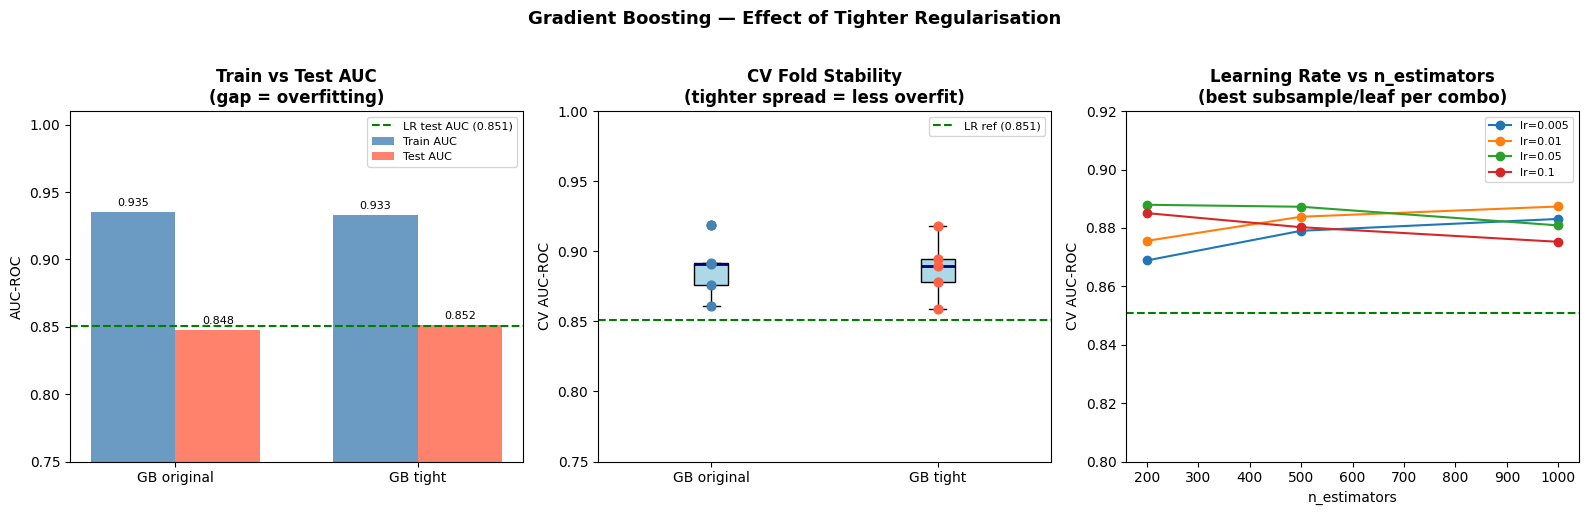

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Tighter grid: shallow trees, slow learning, strong subsampling ────────────
# Key levers for GB regularisation:
#   max_depth=2     — stumps; forces ensemble to do the heavy lifting, not individual trees
#   learning_rate   — shrinks each tree's contribution; lower = less overfit but needs more trees
#   subsample < 1   — stochastic gradient boosting; each tree sees a random row sample
#   min_samples_leaf — prevents splits on tiny groups of noisy training examples
tight_grid = {
    "max_depth":        [2],                        # fix at stumps — strongest regulariser
    "learning_rate":    [0.005, 0.01, 0.05, 0.1],  # much slower than before
    "n_estimators":     [200, 500, 1000],           # more trees to compensate slow LR
    "subsample":        [0.5, 0.7, 0.9],            # row subsampling
    "min_samples_leaf": [5, 10, 20],                # leaf size floor
}

gb_tight = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    tight_grid,
    cv=cv2,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)
gb_tight.fit(X2_train, y2_train)
best_gb_tight = gb_tight.best_estimator_

# ── Compare old vs new GB ─────────────────────────────────────────────────────
old_gb   = improved_models["Gradient Boosting v2"]
old_cv   = cross_val_score(old_gb,        X2_train, y2_train, cv=cv2, scoring="roc_auc")
tight_cv = cross_val_score(best_gb_tight, X2_train, y2_train, cv=cv2, scoring="roc_auc")

old_train = roc_auc_score(y2_train, old_gb.predict_proba(X2_train)[:, 1])
old_test  = roc_auc_score(y2_test,  old_gb.predict_proba(X2_test)[:, 1])
new_train = roc_auc_score(y2_train, best_gb_tight.predict_proba(X2_train)[:, 1])
new_test  = roc_auc_score(y2_test,  best_gb_tight.predict_proba(X2_test)[:, 1])

best_lr_test = roc_auc_score(y2_test, improved_models["Logistic Regression v2"].predict_proba(X2_test)[:, 1])

print("── Best params (tight search) ──────────────────────────────────────────")
print(gb_tight.best_params_)
print()
print(f"{'':30s}  {'Train AUC':>9}  {'Test AUC':>8}  {'Gap':>6}  {'CV mean±std'}")
print("-" * 75)
print(f"{'GB original':30s}  {old_train:>9.3f}  {old_test:>8.3f}  {old_train-old_test:>+6.3f}  {old_cv.mean():.3f} ± {old_cv.std():.3f}")
print(f"{'GB tight (new)':30s}  {new_train:>9.3f}  {new_test:>8.3f}  {new_train-new_test:>+6.3f}  {tight_cv.mean():.3f} ± {tight_cv.std():.3f}")
print(f"{'Logistic Regression (ref)':30s}  {'—':>9}  {best_lr_test:>8.3f}  {'—':>6}  (reference)")

# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Train vs Test AUC comparison ---
ax = axes[0]
models_compare = ["GB original", "GB tight", "LR (reference)"]
train_aucs = [old_train, new_train, None]
test_aucs  = [old_test,  new_test,  best_lr_test]
x = np.arange(len(models_compare))
w = 0.35
bars_train = ax.bar(x[:2] - w/2, train_aucs[:2], w, label="Train AUC", color="steelblue", alpha=0.8)
bars_test  = ax.bar(x[:2] + w/2, test_aucs[:2],  w, label="Test AUC",  color="tomato",    alpha=0.8)
ax.axhline(best_lr_test, color="green", linestyle="--", lw=1.5, label=f"LR test AUC ({best_lr_test:.3f})")
ax.set_xticks(x[:2]); ax.set_xticklabels(models_compare[:2])
ax.set_ylim(0.75, 1.01); ax.set_ylabel("AUC-ROC")
ax.set_title("Train vs Test AUC\n(gap = overfitting)", fontweight="bold")
ax.legend(fontsize=8)
for bar in list(bars_train) + list(bars_test):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

# --- Plot 2: CV fold scores distribution ---
ax = axes[1]
ax.boxplot([old_cv, tight_cv], labels=["GB original", "GB tight"], patch_artist=True,
           boxprops=dict(facecolor="lightblue"), medianprops=dict(color="navy", lw=2))
ax.scatter([1]*5, old_cv,   color="steelblue", zorder=5, s=40)
ax.scatter([2]*5, tight_cv, color="tomato",    zorder=5, s=40)
ax.axhline(best_lr_test, color="green", linestyle="--", lw=1.5, label=f"LR ref ({best_lr_test:.3f})")
ax.set_ylabel("CV AUC-ROC"); ax.set_ylim(0.75, 1.0)
ax.set_title("CV Fold Stability\n(tighter spread = less overfit)", fontweight="bold")
ax.legend(fontsize=8)

# --- Plot 3: learning rate / n_estimators effect from CV results ---
ax = axes[2]
cv_results = pd.DataFrame(gb_tight.cv_results_)
for lr_val in [0.005, 0.01, 0.05, 0.1]:
    subset = cv_results[cv_results["param_learning_rate"] == lr_val]
    grouped = subset.groupby("param_n_estimators")["mean_test_score"].max()
    ax.plot(grouped.index, grouped.values, "o-", label=f"lr={lr_val}")
ax.set_xlabel("n_estimators")
ax.set_ylabel("CV AUC-ROC")
ax.set_title("Learning Rate vs n_estimators\n(best subsample/leaf per combo)", fontweight="bold")
ax.legend(fontsize=8); ax.set_ylim(0.80, 0.92)
ax.axhline(best_lr_test, color="green", linestyle="--", lw=1.5, label=f"LR ref")

plt.suptitle("Gradient Boosting — Effect of Tighter Regularisation",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Part 6: Final Model Comparison

All five models (four improved + GB tight) are compared on:
- Test AUC, Train/Test gap (overfitting gauge), and CV stability
- Survival probability predictions across 18 archetypal passenger profiles

ALL MODEL PERFORMANCE SUMMARY
                 Model  Train AUC  Test AUC    Gap  CV mean  CV std
    GB tight (depth=2)     0.9328    0.8516 0.0812   0.8879  0.0195
Logistic Regression v2     0.8712    0.8507 0.0205   0.8674  0.0171
  Gradient Boosting v2     0.9355    0.8480 0.0875   0.8876  0.0191
      Random Forest v2     0.9495    0.8469 0.1026   0.8795  0.0228
      Decision Tree v2     0.8961    0.8243 0.0718   0.8714  0.0249


SURVIVAL PROBABILITY BY PASSENGER PROFILE
                               Logistic Regression v2  Decision Tree v2  Random Forest v2  Gradient Boosting v2  GB tight (depth=2)  Consensus
Woman · 1st · middle-aged                       0.889             0.968             0.977                 0.944               0.950      0.946
Woman · 1st · young                             0.907             0.968             0.931                 0.898               0.892      0.919
Child · 1st                                     0.769             1.000             0.825

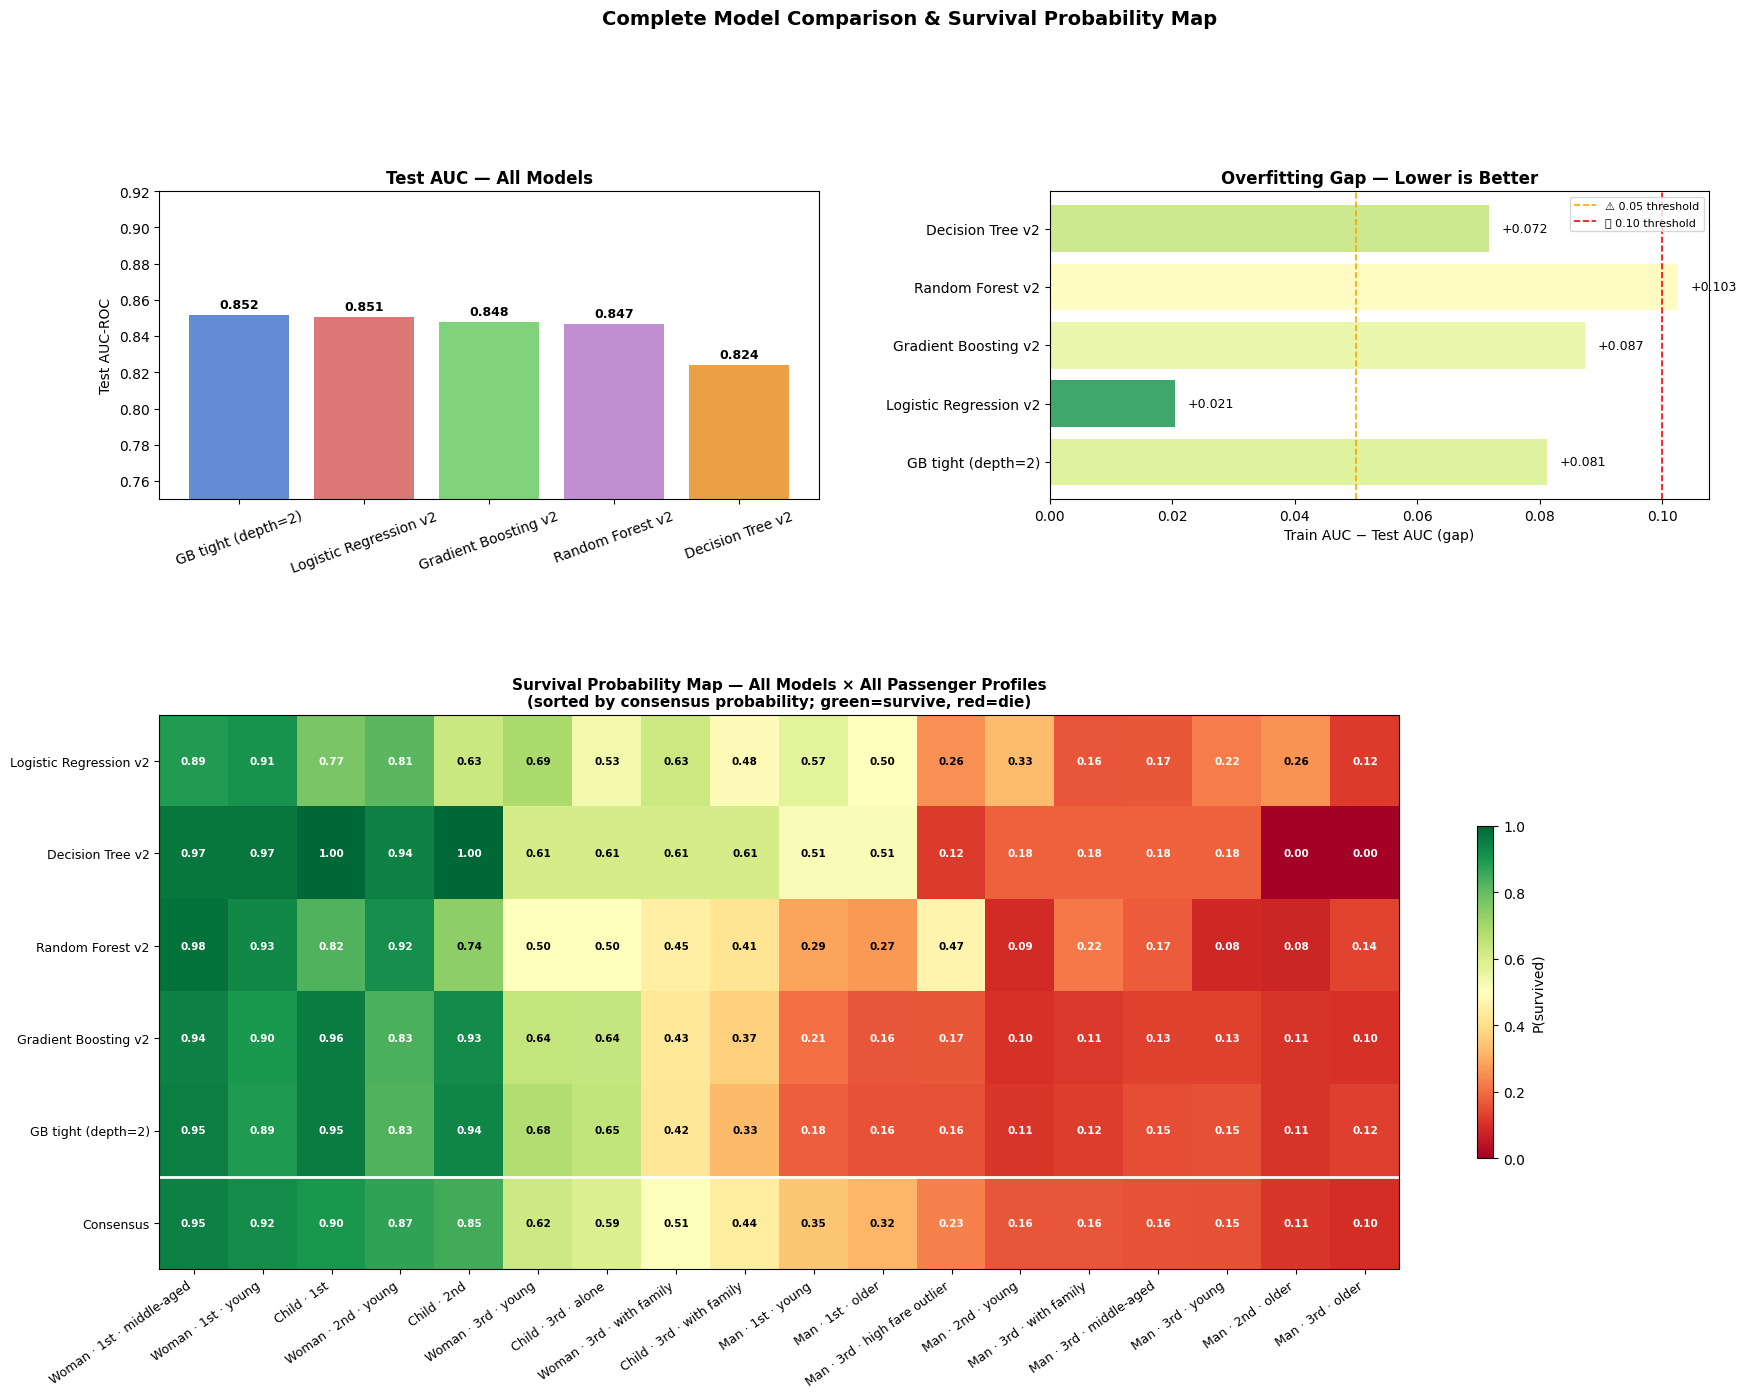

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Build the full model registry ─────────────────────────────────────────────
# GB tight is added only if the tight grid search has been run
all_models = dict(improved_models)   # LR v2, DT v2, RF v2, GB v2
try:
    all_models["GB tight (depth=2)"] = best_gb_tight
except NameError:
    print("⚠  Run the tight GB grid search cell first to include GB tight.")

# ── Performance summary table ─────────────────────────────────────────────────
rows = []
for name, model in all_models.items():
    train_auc = roc_auc_score(y2_train, model.predict_proba(X2_train)[:, 1])
    test_auc  = roc_auc_score(y2_test,  model.predict_proba(X2_test)[:, 1])
    cv_scores = cross_val_score(model, X2_train, y2_train, cv=cv2, scoring="roc_auc")
    rows.append({
        "Model":      name,
        "Train AUC":  round(train_auc, 4),
        "Test AUC":   round(test_auc, 4),
        "Gap":        round(train_auc - test_auc, 4),
        "CV mean":    round(cv_scores.mean(), 4),
        "CV std":     round(cv_scores.std(), 4),
    })

perf_df = pd.DataFrame(rows).sort_values("Test AUC", ascending=False)
print("=" * 75)
print("ALL MODEL PERFORMANCE SUMMARY")
print("=" * 75)
print(perf_df.to_string(index=False))

# ── Survival probability map ──────────────────────────────────────────────────
feature_cols = ['pclass','sex','age','alone','family_size','age_pclass',
                'log_fare','embarked_C','embarked_Q','embarked_S',
                'who_child','who_man','who_woman']

def make_passenger(pclass, sex_str, age, who_str,
                   fare=None, family_size=1, embarked="S"):
    """Build a single-row feature dict."""
    sex    = 0 if sex_str == "female" else 1
    fare   = fare if fare is not None else {1: 80, 2: 15, 3: 8}[pclass]
    emb_C  = 1 if embarked == "C" else 0
    emb_Q  = 1 if embarked == "Q" else 0
    emb_S  = 1 if embarked == "S" else 0
    return {
        "pclass": pclass, "sex": sex, "age": age,
        "alone": int(family_size == 1), "family_size": family_size,
        "age_pclass": age * pclass, "log_fare": np.log1p(fare),
        "embarked_C": emb_C, "embarked_Q": emb_Q, "embarked_S": emb_S,
        "who_child": 1 if who_str == "child" else 0,
        "who_man":   1 if who_str == "man"   else 0,
        "who_woman": 1 if who_str == "woman" else 0,
    }

# 18 archetypal passengers covering key intersections of class / gender / age
profile_specs = [
    # label,                          pclass, sex,      age, who,     fare, fam
    ("Woman · 1st · young",               1, "female",  25, "woman", 150,  2),
    ("Woman · 1st · middle-aged",         1, "female",  45, "woman", 150,  2),
    ("Woman · 2nd · young",               2, "female",  25, "woman",  30,  1),
    ("Woman · 3rd · young",               3, "female",  22, "woman",   8,  1),
    ("Woman · 3rd · with family",         3, "female",  28, "woman",  15,  4),
    ("Child · 1st",                       1, "male",     8, "child",  80,  3),
    ("Child · 2nd",                       2, "male",     8, "child",  20,  3),
    ("Child · 3rd · alone",               3, "male",     8, "child",   8,  1),
    ("Child · 3rd · with family",         3, "male",    10, "child",  15,  4),
    ("Man · 1st · young",                 1, "male",    28, "man",   200,  1),
    ("Man · 1st · older",                 1, "male",    55, "man",   200,  2),
    ("Man · 2nd · young",                 2, "male",    28, "man",    20,  1),
    ("Man · 2nd · older",                 2, "male",    50, "man",    20,  1),
    ("Man · 3rd · young",                 3, "male",    22, "man",     8,  1),
    ("Man · 3rd · middle-aged",           3, "male",    38, "man",     8,  1),
    ("Man · 3rd · older",                 3, "male",    55, "man",     8,  1),
    ("Man · 3rd · with family",           3, "male",    32, "man",    15,  4),
    ("Man · 3rd · high fare outlier",     3, "male",    30, "man",    50,  1),
]

records   = [make_passenger(pc, sx, ag, wh, fare=fa, family_size=fm)
             for _, pc, sx, ag, wh, fa, fm in profile_specs]
labels    = [s[0] for s in profile_specs]
profile_X = pd.DataFrame(records, columns=feature_cols)

# Get predictions from every model
pred_dict = {}
for name, model in all_models.items():
    pred_dict[name] = model.predict_proba(profile_X)[:, 1].round(3)

pred_df = pd.DataFrame(pred_dict, index=labels)
pred_df["Consensus"] = pred_df.mean(axis=1).round(3)
pred_df = pred_df.sort_values("Consensus", ascending=False)

print("\n\nSURVIVAL PROBABILITY BY PASSENGER PROFILE")
print("=" * 90)
print(pred_df.to_string())

# ── Figure: heatmap + gap chart ────────────────────────────────────────────────
cmap_rg = plt.cm.RdYlGn
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.35,
                        height_ratios=[1, 1.8])

# Panel 1 (top-left): Test AUC comparison bar
ax1 = fig.add_subplot(gs[0, 0])
colours = ["#4878CF","#D65F5F","#6ACC65","#B47CC7","#E88F24"][:len(perf_df)]
bars = ax1.bar(perf_df["Model"], perf_df["Test AUC"], color=colours, alpha=0.85)
ax1.set_ylim(0.75, 0.92)
ax1.set_ylabel("Test AUC-ROC")
ax1.set_title("Test AUC — All Models", fontweight="bold")
ax1.tick_params(axis="x", rotation=20)
for bar, val in zip(bars, perf_df["Test AUC"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Panel 2 (top-right): Train/Test gap — overfitting gauge
ax2 = fig.add_subplot(gs[0, 1])
gap_colours = [cmap_rg(1 - min(g / 0.2, 1)) for g in perf_df["Gap"]]
bars2 = ax2.barh(perf_df["Model"], perf_df["Gap"], color=gap_colours, alpha=0.85)
ax2.axvline(0.05, color="orange", linestyle="--", lw=1.2, label="⚠ 0.05 threshold")
ax2.axvline(0.10, color="red",    linestyle="--", lw=1.2, label="🚨 0.10 threshold")
ax2.set_xlabel("Train AUC − Test AUC (gap)")
ax2.set_title("Overfitting Gap — Lower is Better", fontweight="bold")
ax2.legend(fontsize=8)
for bar, val in zip(bars2, perf_df["Gap"]):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:+.3f}", va="center", fontsize=9)

# Panel 3 (bottom, full width): Survival probability heatmap
ax3 = fig.add_subplot(gs[1, :])
model_cols = list(all_models.keys()) + ["Consensus"]
heat_vals  = pred_df[model_cols].values
im = ax3.imshow(heat_vals.T, cmap=cmap_rg, vmin=0, vmax=1, aspect="auto")
ax3.set_xticks(range(len(pred_df)))
ax3.set_xticklabels(pred_df.index, rotation=35, ha="right", fontsize=9)
ax3.set_yticks(range(len(model_cols)))
ax3.set_yticklabels(model_cols, fontsize=9)
ax3.set_title("Survival Probability Map — All Models × All Passenger Profiles\n"
              "(sorted by consensus probability; green=survive, red=die)",
              fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax3, label="P(survived)", shrink=0.6)
for r in range(heat_vals.shape[0]):
    for c in range(heat_vals.shape[1]):
        val = heat_vals[r, c]
        txt_col = "black" if 0.25 < val < 0.75 else "white"
        ax3.text(r, c, f"{val:.2f}", ha="center", va="center",
                 fontsize=7.5, color=txt_col, fontweight="bold")

# Separator line between consensus col and model cols
ax3.axhline(len(model_cols) - 1.5, color="white", lw=2)

fig.suptitle("Complete Model Comparison & Survival Probability Map",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Survival Probability Heatmap — 5 Archetypal Profiles

The five profiles below represent the extremes and ambiguous middle-ground of the Titanic survival distribution. The heatmap shows each model's predicted P(survived); the bar chart shows the model consensus. Profiles where models disagree most are the most informative about where each model has learned different decision boundaries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

feature_cols = ['pclass','sex','age','alone','family_size','age_pclass',
                'log_fare','embarked_C','embarked_Q','embarked_S',
                'who_child','who_man','who_woman']

core_profiles = {
    "Female · 1st class · high fare\n(who_woman)": {
        "pclass":1,"sex":0,"age":35,"alone":0,"family_size":3,
        "age_pclass":35,"log_fare":np.log1p(150),
        "embarked_C":1,"embarked_Q":0,"embarked_S":0,
        "who_child":0,"who_man":0,"who_woman":1,
    },
    "Male · 3rd class · low fare\n(who_man)": {
        "pclass":3,"sex":1,"age":28,"alone":1,"family_size":1,
        "age_pclass":84,"log_fare":np.log1p(8),
        "embarked_C":0,"embarked_Q":0,"embarked_S":1,
        "who_child":0,"who_man":1,"who_woman":0,
    },
    "Male child · 3rd class · low fare\n(who_child)": {
        "pclass":3,"sex":1,"age":8,"alone":0,"family_size":4,
        "age_pclass":24,"log_fare":np.log1p(15),
        "embarked_C":0,"embarked_Q":0,"embarked_S":1,
        "who_child":1,"who_man":0,"who_woman":0,
    },
    "Female · 3rd class · low fare\n(who_woman)": {
        "pclass":3,"sex":0,"age":22,"alone":1,"family_size":1,
        "age_pclass":66,"log_fare":np.log1p(7),
        "embarked_C":0,"embarked_Q":0,"embarked_S":1,
        "who_child":0,"who_man":0,"who_woman":1,
    },
    "Male · 1st class · high fare\n(who_man)": {
        "pclass":1,"sex":1,"age":50,"alone":0,"family_size":2,
        "age_pclass":50,"log_fare":np.log1p(200),
        "embarked_C":1,"embarked_Q":0,"embarked_S":0,
        "who_child":0,"who_man":1,"who_woman":0,
    },
}

profile_X = pd.DataFrame(core_profiles).T[feature_cols]

# ── Collect predictions ───────────────────────────────────────────────────────
model_set = dict(improved_models)
try:
    model_set["GB tight (depth=2)"] = best_gb_tight
except NameError:
    print("⚠  Run tight GB cell to include GB tight.")

col_labels = {
    "Logistic Regression v2": "Logistic\nRegression",
    "Decision Tree v2":       "Decision\nTree",
    "Random Forest v2":       "Random\nForest",
    "Gradient Boosting v2":   "Gradient\nBoosting",
    "GB tight (depth=2)":     "GB tight\n(depth=2)",
}

pred = {col_labels.get(n, n): m.predict_proba(profile_X)[:, 1].round(3)
        for n, m in model_set.items()}
pred_df   = pd.DataFrame(pred, index=core_profiles.keys())
consensus = pred_df.mean(axis=1).round(3)

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = plt.cm.RdYlGn
fig  = plt.figure(figsize=(14, 5))
gs   = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35,
                         width_ratios=[len(model_set), 1.4])

model_names   = list(pred_df.columns)
profile_names = list(core_profiles.keys())
heat          = pred_df[model_names].values   # shape: (profiles × models)

# Left: heatmap
ax_heat = fig.add_subplot(gs[0])
im = ax_heat.imshow(heat, cmap=cmap, vmin=0, vmax=1, aspect="auto")
ax_heat.set_xticks(range(len(model_names)))
ax_heat.set_xticklabels(model_names, fontsize=9)
ax_heat.set_yticks(range(len(profile_names)))
ax_heat.set_yticklabels(profile_names, fontsize=9)
ax_heat.set_title("Predicted Survival Probability — All Models", fontweight="bold", fontsize=11)
for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        val = heat[r, c]
        txt_col = "black" if 0.25 < val < 0.75 else "white"
        ax_heat.text(c, r, f"{val:.2f}", ha="center", va="center",
                     fontsize=10, color=txt_col, fontweight="bold")
plt.colorbar(im, ax=ax_heat, label="P(survived)", fraction=0.03, pad=0.03)

# Right: consensus bar
ax_bar = fig.add_subplot(gs[1])
bar_colours = [cmap(v) for v in consensus.values]
bars = ax_bar.barh(range(len(profile_names)), consensus.values,
                   color=bar_colours, edgecolor="gray", height=0.6)
ax_bar.set_xlim(0, 1.08)
ax_bar.axvline(0.5, color="black", linestyle="--", lw=1.2)
ax_bar.set_yticks(range(len(profile_names)))
ax_bar.set_yticklabels(profile_names, fontsize=9)
ax_bar.set_xlabel("Mean predicted P(survived)")
ax_bar.set_title("Model Consensus", fontweight="bold", fontsize=11)
for bar, val in zip(bars, consensus.values):
    ax_bar.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()